In [1]:
import json

import logomaker as lm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyliftover
import seaborn as sns
from pyfaidx import Fasta
from scipy.stats import chi2_contingency

from analysis_functions import (
                        calculate_chi2_p_values,
                        filter_and_convert_to_list,
                        check_ref,
                        get_codon_info,
                        get_context
                    )

In [2]:
clinvar_undergo_df = pd.read_csv("data/clinvar_nmd_undergo_df.csv")

In [3]:
clinvar_escape_df = pd.read_csv("data/clinvar_nmd_escape_df.csv")

In [4]:
clinvar_escape_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'CLNREVSTAT', 'CLNSIG', 'CLNVC',
       'GENEINFO', 'MC', 'Consequence', 'SYMBOL', 'Gene', 'Feature_type',
       'Feature', 'BIOTYPE', 'cDNA_position', 'CDS_position',
       'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'FLAGS',
       'CANONICAL', 'LOEUF', 'pext', 'NMD_escape'],
      dtype='object')

## 3. Get sequence context

Write the context in the corresponding column of the dataframe.

File `gencode.v47.transcripts.fa.gz` can be downloaded from the GENCODE database (https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_47/gencode.v47.transcripts.fa.gz).

In [5]:
clinvar_undergo_df['cDNA_position'] = clinvar_undergo_df['cDNA_position'].astype(int)

In [6]:
clinvar_escape_df['cDNA_position'] = clinvar_escape_df['cDNA_position'].astype(int)

In [7]:
transcript_fasta = Fasta("data/gencode.v47.transcripts.fa.gz", key_function = lambda x: x.split('.')[0])

In [8]:
get_context(clinvar_escape_df, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

In [9]:
get_context(clinvar_undergo_df, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

## 4. Get variant codons information

In [10]:
def get_codon_position(codon_change):
    codon = codon_change.split('/')[0]  # первый кодон (до слэша)
    for i, base in enumerate(codon, start=1):
        if base.isupper():
            return i
    return None  # если вдруг нет заглавной буквы

In [11]:
clinvar_escape_df['Codon_position'] = clinvar_escape_df['Codons'].apply(get_codon_position)

In [12]:
clinvar_escape_df['Codon_position'].value_counts()

Codon_position
1    763
2    233
3    232
Name: count, dtype: int64

In [13]:
clinvar_undergo_df['Codon_position'] = clinvar_undergo_df['Codons'].apply(get_codon_position)

In [14]:
clinvar_undergo_df['Codon_position'].value_counts()

Codon_position
1    4590
3    1341
2    1171
Name: count, dtype: int64

In [15]:
def get_initial_codon(codon_change):
    return codon_change.split('/')[0].upper()

def get_stop_codon(codon_change):
    return codon_change.split('/')[1].upper()

In [16]:
clinvar_escape_df['Initial_Codon'] = clinvar_escape_df['Codons'].apply(get_initial_codon)
clinvar_escape_df['Stop_Codon'] = clinvar_escape_df['Codons'].apply(get_stop_codon)

In [17]:
clinvar_escape_df['Codon_change'] = list(zip(clinvar_escape_df['Initial_Codon'], clinvar_escape_df['Stop_Codon']))
clinvar_escape_df['Codon_change'].value_counts(normalize=True) * 100

Codon_change
(CAG, TAG)    19.706840
(CGA, TGA)    12.622150
(GAA, TAA)     7.084691
(GAG, TAG)     7.003257
(TCA, TGA)     6.107492
(CAA, TAA)     5.863192
(TAC, TAG)     4.885993
(TGG, TGA)     4.071661
(AAG, TAG)     3.990228
(TCA, TAA)     3.827362
(TAC, TAA)     3.501629
(TGG, TAG)     3.094463
(TCG, TAG)     2.442997
(AAA, TAA)     2.198697
(TTA, TGA)     2.198697
(GGA, TGA)     2.117264
(TAT, TAG)     2.035831
(TGC, TGA)     1.791531
(TAT, TAA)     1.547231
(AGA, TGA)     1.547231
(TGT, TGA)     1.058632
(TTG, TAG)     0.651466
(TTA, TAA)     0.651466
Name: proportion, dtype: float64

In [18]:
clinvar_undergo_df['Initial_Codon'] = clinvar_undergo_df['Codons'].apply(get_initial_codon)
clinvar_undergo_df['Stop_Codon'] = clinvar_undergo_df['Codons'].apply(get_stop_codon)

In [19]:
clinvar_undergo_df['Codon_change'] = list(zip(clinvar_undergo_df['Initial_Codon'], clinvar_undergo_df['Stop_Codon']))
clinvar_undergo_df['Codon_change'].value_counts(normalize=True) * 100

Codon_change
(CAG, TAG)    20.135173
(CGA, TGA)    16.784005
(GAA, TAA)     6.505210
(GAG, TAG)     6.420727
(CAA, TAA)     6.139116
(TGG, TAG)     5.322444
(TGG, TGA)     4.914109
(TCA, TGA)     3.491974
(TAC, TAG)     3.477894
(TAC, TAA)     3.196283
(AAG, TAG)     3.041397
(GGA, TGA)     2.365531
(AAA, TAA)     2.323289
(TAT, TAG)     2.238806
(TGC, TGA)     2.224725
(TCA, TAA)     1.971276
(TTA, TGA)     1.886792
(TAT, TAA)     1.830470
(TTG, TAG)     1.337651
(TCG, TAG)     1.309490
(TTA, TAA)     1.168685
(TGT, TGA)     0.999718
(AGA, TGA)     0.915235
Name: proportion, dtype: float64

## 8. Relationship between the significance of a variant and its position in a codon

In [20]:
all_clinvar_final = pd.concat([clinvar_escape_df, clinvar_undergo_df], ignore_index=True)

In [21]:
all_clinvar_final.to_csv('data/all_clinvar_with_codon_info.csv', index=False)

In [22]:
all_clinvar_final

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,FLAGS,CANONICAL,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Codon_change
0,chr1,12009699,2682761,C,A,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,NaN,YES,0.282,0.971272,YES,AGGTTCTTGACTCACTTCAGAGCAA,2,TCA,TAA,"(TCA, TAA)"
1,chr1,12009699,933991,C,G,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,NaN,YES,0.282,0.971272,YES,AGGTTCTTGACTCACTTCAGAGCAA,2,TCA,TGA,"(TCA, TGA)"
2,chr1,12011511,1172816,G,A,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,NaN,YES,0.282,0.971272,YES,TAAAGCCGGTTGGTTGGACAGTGAG,3,TGG,TGA,"(TGG, TGA)"
3,chr1,12011542,572169,C,T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,NaN,YES,0.282,0.971272,YES,ATGTTCACACACCAGTACCTGCAGC,1,CAG,TAG,"(CAG, TAG)"
4,chr1,12011547,217162,C,A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,MFN2:9927,SO:0001587|nonsense,...,NaN,YES,0.282,0.971272,YES,CACACACCAGTACCTGCAGCCCAGC,3,TAC,TAA,"(TAC, TAA)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8325,chr22,41176400,183678,C,T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,NaN,YES,0.099,1.000000,NO,TTCTCTTCACTCCGAAGAGCCCAGT,1,CGA,TGA,"(CGA, TGA)"
8326,chr22,50447442,1301645,G,C,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,NaN,YES,0.265,0.771752,NO,GCTGCGCTACTACGACCACCGTGTG,3,TAC,TAG,"(TAC, TAG)"
8327,chr22,50448330,3644969,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,NaN,YES,0.265,0.771752,NO,CTGGACAGCGACCAGAGTAGTGGCT,1,CAG,TAG,"(CAG, TAG)"
8328,chr22,50448592,2018999,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,NaN,YES,0.265,0.771752,NO,GGAAGGACACCTGGGACCGGGTGAA,2,TGG,TAG,"(TGG, TAG)"


In [23]:
all_clinvar_final.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'CLNREVSTAT', 'CLNSIG', 'CLNVC',
       'GENEINFO', 'MC', 'Consequence', 'SYMBOL', 'Gene', 'Feature_type',
       'Feature', 'BIOTYPE', 'cDNA_position', 'CDS_position',
       'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'FLAGS',
       'CANONICAL', 'LOEUF', 'pext', 'NMD_escape', 'Context', 'Codon_position',
       'Initial_Codon', 'Stop_Codon', 'Codon_change'],
      dtype='object')

In [24]:
stop_codon_types = ['TAA', 'TAG', 'TGA']
count_df = all_clinvar_final.groupby(['Stop_Codon', 'NMD_escape']).size().unstack(fill_value=0)
percent_df = count_df.div(count_df.sum(axis=0), axis=1) * 100

percent_df

NMD_escape,NO,YES
Stop_Codon,,
TAA,23.134328,24.674267
TAG,43.283582,43.811075
TGA,33.582090,31.514658


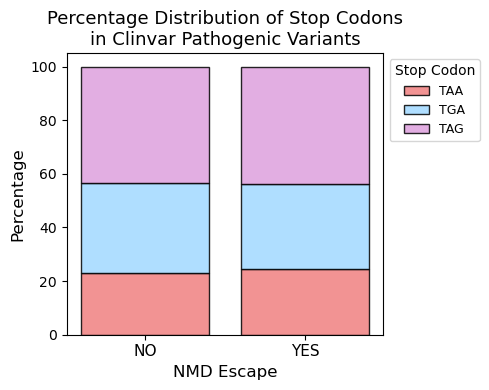

In [27]:
stop_codons_df = all_clinvar_final[all_clinvar_final['Stop_Codon'].isin(['TAA', 'TGA', 'TAG'])]

grouped = stop_codons_df.groupby(['NMD_escape', 'Stop_Codon']).size().unstack(fill_value=0)

grouped_percent = grouped.div(grouped.sum(axis=1), axis=0) * 100

stop_codon_types = ['TAA', 'TGA', 'TAG']
grouped_percent = grouped_percent[stop_codon_types]

x = np.arange(len(grouped_percent.index))  # [Undergo, Escape]
colors = ['#f08080', '#a1d9ff', '#dda0dd']

fig, ax = plt.subplots(figsize=(5, 4))
bottom = np.zeros(len(x))

for codon, color in zip(stop_codon_types, colors):
    values = grouped_percent[codon].values
    ax.bar(x, values, label=codon, bottom=bottom, color=color, edgecolor='black', alpha=0.85)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(grouped_percent.index, fontsize=11)
ax.set_ylabel('Percentage', fontsize=12)
ax.set_xlabel('NMD Escape', fontsize=12)
ax.set_title('Percentage Distribution of Stop Codons\nin Clinvar Pathogenic Variants', fontsize=13)

plt.legend(title='Stop Codon', fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
